# External OSS Spark Access to Unity Catalog Iceberg Tables

## Overview

This notebook demonstrates the **architecture and configuration** for enabling external open-source Apache Spark clients to access Unity Catalog managed Iceberg tables. This showcases Unity Catalog's open standards approach and vendor-neutral data access capabilities.

## What This Demo Shows

- 🏗️ **Architecture**: How external Spark connects to Unity Catalog
- 🔧 **Configuration**: Complete Spark session setup with Iceberg dependencies
- 🔐 **Authentication**: REST API with token-based access
- 🔑 **Credential Vending**: How Unity Catalog provides temporary S3 credentials
- 📊 **Query Patterns**: SQL queries against Unity Catalog tables
- ⚾ **Use Case**: MLB pitch-by-pitch analytics data

## Architecture Diagram

```
External OSS Spark (Your Laptop)
           ↓
    1. Authenticate with Token
           ↓
Unity Catalog REST API
/api/2.1/unity-catalog/iceberg
           ↓
    2. Vend Temporary S3 Credentials
    3. Return Table Metadata
           ↓
S3 Storage (Iceberg Data Files)
 - Parquet files
 - Manifest files
 - Metadata files
```

## Key Benefits

- **🔓 No Vendor Lock-in**: Use any Spark-compatible platform
- **🎯 Centralized Governance**: Unity Catalog maintains all metadata and permissions
- **🌐 Open Standards**: Built on Apache Iceberg REST specification
- **🔐 Secure Access**: Temporary credentials with time-limited access
- **💰 Cost Optimization**: Run analytics on your own compute

## Prerequisites

**On Unity Catalog Side (Admin Required):**
- External location configured for the catalog
- Storage credential with appropriate S3/cloud permissions
- Table must support external access
- Access token with SELECT permissions

**On Client Side:**
- Python 3.8+, PySpark 3.5+
- Iceberg Spark Runtime libraries
- AWS SDK libraries (for S3 access)


In [1]:
# Install required dependencies
# Uncomment to install in a fresh environment
# !pip install pyspark==3.5.1 pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Packages will be automatically downloaded via Spark:
# - org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.4.2
# - org.apache.iceberg:iceberg-aws-bundle:1.4.2  
# - software.amazon.awssdk:s3:2.20.89
# - software.amazon.awssdk:auth:2.20.89


In [2]:
from config import *


## 1. Spark Session Configuration

### Understanding the Configuration

The Spark session needs several key configurations:

1. **Iceberg Extensions**: Enable Iceberg table support in Spark
2. **REST Catalog**: Configure Unity Catalog as a REST catalog
3. **Authentication**: Bearer token for API access
4. **Credential Vending**: Enable Unity Catalog to provide temporary S3 credentials
5. **S3 FileIO**: Use Iceberg's S3FileIO for cloud storage access

### Credential Vending Flow

When you query a table:
1. Spark asks Unity Catalog: "What files do I need to read?"
2. Unity Catalog responds with:
   - List of S3 file paths
   - Temporary AWS credentials (valid for ~1 hour)
   - Credential expiration time
3. Spark uses those credentials to read directly from S3
4. Unity Catalog tracks the access for audit/lineage


In [3]:
import os
from pyspark.sql import SparkSession

# Set AWS region as environment variable
os.environ["AWS_REGION"] = AWS_REGION
os.environ["AWS_DEFAULT_REGION"] = AWS_REGION

# Add Iceberg + AWS dependencies via Spark packages
os.environ["PYSPARK_SUBMIT_ARGS"] = (
    "--packages "
    "org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.4.2,"
    "org.apache.iceberg:iceberg-aws-bundle:1.4.2,"
    "software.amazon.awssdk:s3:2.20.89,"
    "software.amazon.awssdk:auth:2.20.89 pyspark-shell"
)

# Create Spark session with Unity Catalog configuration
spark = SparkSession.builder \
    .appName("Unity Catalog External Access Demo") \
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}", "org.apache.iceberg.spark.SparkCatalog") \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}.type", "rest") \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}.uri", f"https://{WORKSPACE_URI}/api/2.1/unity-catalog/iceberg-rest") \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}.header.Authorization", f"Bearer {ACCESS_TOKEN}") \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}.warehouse", UC_CATALOG_NAME) \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}.credential-vending-enabled", "true") \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}.io-impl", "org.apache.iceberg.aws.s3.S3FileIO") \
    .config(f"spark.sql.catalog.{UC_CATALOG_NAME}.client.region", AWS_REGION) \
    .getOrCreate()

print("✅ Spark session created successfully!")
print(f"   Spark version: {spark.version}")
print(f"   Configured catalog: {UC_CATALOG_NAME}")
print(f"   Workspace: {WORKSPACE_URI}")
print(f"\\n🔐 Security:")
print(f"   - REST API authentication with Bearer token")
print(f"   - Credential vending enabled (temporary S3 access)")
print(f"   - All access logged in Unity Catalog")


:: loading settings :: url = jar:file:/Users/alexander.booth/miniconda3/envs/demo-env/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/alexander.booth/.ivy2/cache
The jars for the packages stored in: /Users/alexander.booth/.ivy2/jars
org.apache.iceberg#iceberg-spark-runtime-3.5_2.12 added as a dependency
org.apache.iceberg#iceberg-aws-bundle added as a dependency
software.amazon.awssdk#s3 added as a dependency
software.amazon.awssdk#auth added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7df99c6b-bff2-4d11-96ba-a7006865d957;1.0
	confs: [default]
	found org.apache.iceberg#iceberg-spark-runtime-3.5_2.12;1.4.2 in central
	found org.apache.iceberg#iceberg-aws-bundle;1.4.2 in central
	found software.amazon.awssdk#s3;2.20.89 in central
	found software.amazon.awssdk#aws-xml-protocol;2.20.89 in central
	found software.amazon.awssdk#aws-query-protocol;2.20.89 in central
	found software.amazon.awssdk#protocol-core;2.20.89 in central
	found software.amazon.awssdk#sdk-core;2.20.89 in central
	found software.amazon.awssdk#annotations;2.20.89 in central
	found so

✅ Spark session created successfully!
   Spark version: 3.5.1
   Configured catalog: mlb_tech_summit
   Workspace: fe-vm-vdm-classic-212e0j.cloud.databricks.com
\n🔐 Security:
   - REST API authentication with Bearer token
   - Credential vending enabled (temporary S3 access)
   - All access logged in Unity Catalog


## 2. Data Exploration & Analytics

Now that we're connected, let's explore the MLB data using OSS Spark and create visualizations with Pandas/Matplotlib.


In [4]:
# Set target table
schema_name = "mlb_gumbo_gold"
table_name = "game_report_iceberg"
full_table_name = f"{UC_CATALOG_NAME}.{schema_name}.{table_name}"

# Configure which league level to analyze
# Options: "Major League Baseball" or "Triple-A"
LEAGUE_LEVEL = "Major League Baseball"  # Change this to "Triple-A" to analyze minor league data

print(f"📊 Target Table: {full_table_name}")
print(f"🏟️  Analyzing: {LEAGUE_LEVEL}")
print(f"\nTable contains:")
print(f"   - MLB pitch-by-pitch data (2023-2025)")
print(f"   - Game metadata (teams, venue, weather)")
print(f"   - Pitch details (type, speed, spin)")
print(f"   - Hit data (exit velocity, launch angle)")
print(f"   - ML predictions (strike probability)")


📊 Target Table: mlb_tech_summit.mlb_gumbo_gold.game_report_iceberg
🏟️  Analyzing: Major League Baseball

Table contains:
   - MLB pitch-by-pitch data (2023-2025)
   - Game metadata (teams, venue, weather)
   - Pitch details (type, speed, spin)
   - Hit data (exit velocity, launch angle)
   - ML predictions (strike probability)


In [5]:
# Get dataset overview
print("📊 Dataset Overview:")
overview_query = f"""
SELECT 
    COUNT(*) as total_pitches,
    COUNT(DISTINCT game_pk) as total_games,
    COUNT(DISTINCT season) as seasons,
    COUNT(DISTINCT pitcher_full_name) as unique_pitchers,
    COUNT(DISTINCT batter_full_name) as unique_batters
FROM {full_table_name}
WHERE level = '{LEAGUE_LEVEL}'
"""

overview = spark.sql(overview_query).toPandas()
print(f"\n{LEAGUE_LEVEL} Stats:")
print(f"   Total Pitches: {overview['total_pitches'][0]:,}")
print(f"   Total Games: {overview['total_games'][0]:,}")
print(f"   Seasons: {overview['seasons'][0]}")
print(f"   Unique Pitchers: {overview['unique_pitchers'][0]:,}")
print(f"   Unique Batters: {overview['unique_batters'][0]:,}")

# Get season breakdown
season_query = f"""
SELECT 
    season,
    COUNT(*) as pitch_count,
    COUNT(DISTINCT game_pk) as game_count
FROM {full_table_name}
WHERE level = '{LEAGUE_LEVEL}'
GROUP BY season
ORDER BY season
"""

season_df = spark.sql(season_query).toPandas()
print(f"\n📅 {LEAGUE_LEVEL} Data by Season:")
print(season_df.to_string(index=False))

📊 Dataset Overview:



Major League Baseball Stats:
   Total Pitches: 1,446,477
   Total Games: 4,949
   Seasons: 2
   Unique Pitchers: 1,112
   Unique Batters: 788



📅 Major League Baseball Data by Season:
 season  pitch_count  game_count
   2024       722297        2472
   2025       724180        2477


In [6]:
### 🏆 Pitcher Performance Analysis

# Top pitchers by average strike probability (min 500 pitches)
print(f"🏆 Top 20 {LEAGUE_LEVEL} Pitchers by Strike Probability (Min 500 pitches):")

pitcher_query = f"""
SELECT 
    pitcher_full_name,
    pitcher_hand_description,
    COUNT(*) as total_pitches,
    ROUND(AVG(called_strike_probability), 3) as avg_strike_prob,
    ROUND(AVG(pitch_start_speed), 1) as avg_velocity,
    ROUND(AVG(pitch_spin_rate), 0) as avg_spin_rate
FROM {full_table_name}
WHERE level = '{LEAGUE_LEVEL}'
    AND called_strike_probability IS NOT NULL
GROUP BY pitcher_full_name, pitcher_hand_description
HAVING COUNT(*) >= 500
ORDER BY avg_strike_prob DESC
LIMIT 20
"""

pitcher_df = spark.sql(pitcher_query).toPandas()
print(pitcher_df.to_string(index=False))


🏆 Top 20 Major League Baseball Pitchers by Strike Probability (Min 500 pitches):


pitcher_full_name pitcher_hand_description  total_pitches  avg_strike_prob  avg_velocity  avg_spin_rate
     Tyler Rogers                    Right           1972            0.611          80.1         2092.0
      Max Kranick                    Right            533            0.562          90.3         2255.0
      Kyle Muller                     Left            722            0.561          88.5         2204.0
 Brandon Woodruff                    Right            964            0.558          90.1         2263.0
    Kenley Jansen                    Right           1665            0.557          91.7         2576.0
    Justin Steele                     Left           2359            0.556          88.5         2482.0
         Tim Hill                     Left           2019            0.554          88.6         2094.0
    Miles Mikolas                    Right           5188            0.553          87.9         2229.0
    Colton Gordon                     Left           1451       

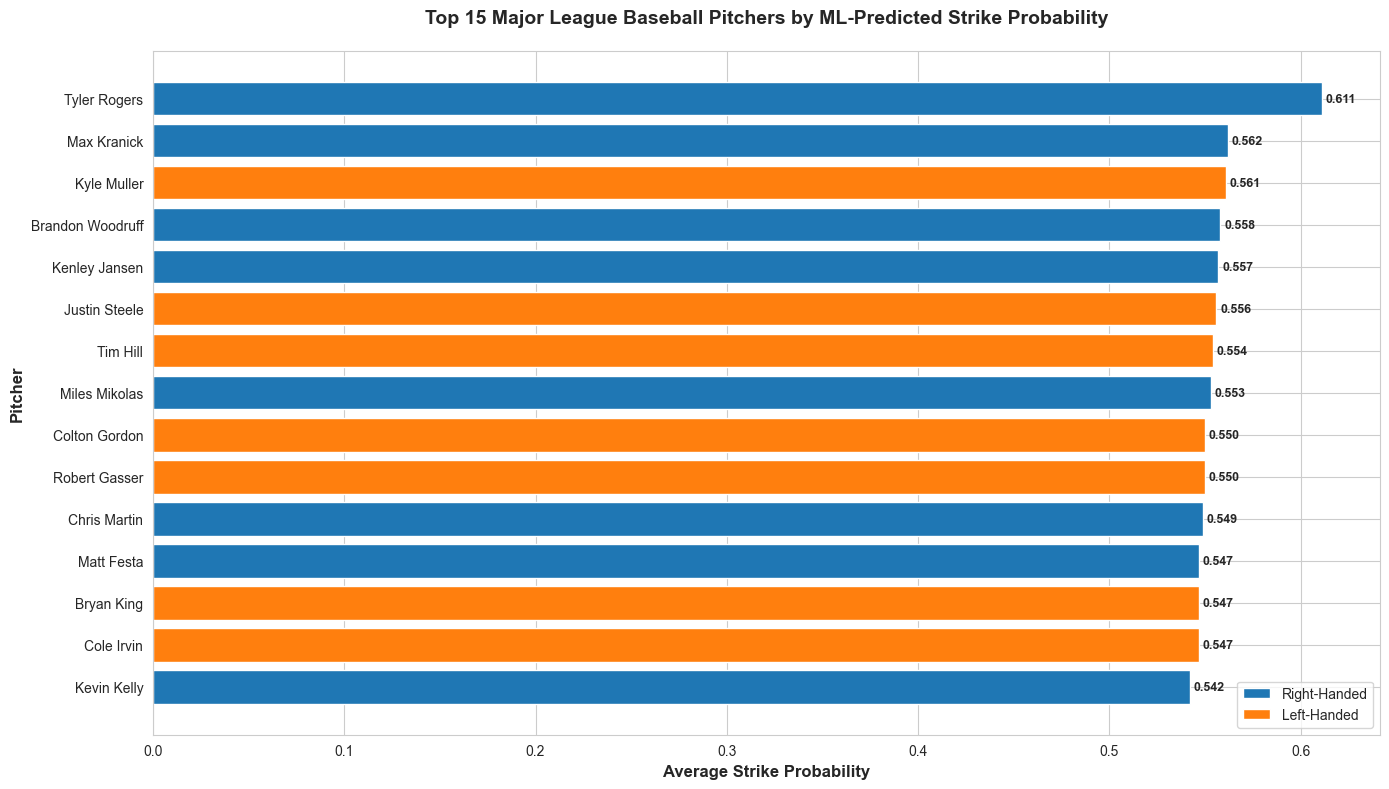


📊 Chart displays the top 15 Major League Baseball pitchers most likely to get called strikes


In [7]:
# Visualize top pitchers
fig, ax = plt.subplots(figsize=(14, 8))

# Take top 15 for better readability
top_15 = pitcher_df.head(15)
colors = ['#1f77b4' if hand == 'Right' else '#ff7f0e' for hand in top_15['pitcher_hand_description']]

bars = ax.barh(top_15['pitcher_full_name'], top_15['avg_strike_prob'], color=colors)
ax.set_xlabel('Average Strike Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Pitcher', fontsize=12, fontweight='bold')
ax.set_title(f'Top 15 {LEAGUE_LEVEL} Pitchers by ML-Predicted Strike Probability', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add value labels on bars
for i, (bar, prob) in enumerate(zip(bars, top_15['avg_strike_prob'])):
    ax.text(prob + 0.002, bar.get_y() + bar.get_height()/2, f'{prob:.3f}', 
            va='center', fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Right-Handed'),
                   Patch(facecolor='#ff7f0e', label='Left-Handed')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Chart displays the top 15 {LEAGUE_LEVEL} pitchers most likely to get called strikes")


### ⚾ Pitch Type Effectiveness


In [8]:
# Analyze pitch type effectiveness
print(f"⚾ {LEAGUE_LEVEL} Pitch Type Effectiveness (Min 1000 pitches):")

pitch_type_query = f"""
SELECT 
    pitch_type_description,
    COUNT(*) as pitch_count,
    ROUND(AVG(pitch_start_speed), 1) as avg_velocity,
    ROUND(AVG(pitch_spin_rate), 0) as avg_spin_rate,
    ROUND(AVG(called_strike_probability), 3) as avg_strike_prob,
    ROUND(100.0 * SUM(CASE WHEN call_description IN ('Called Strike', 'Swinging Strike') THEN 1 ELSE 0 END) / COUNT(*), 1) as strike_pct
FROM {full_table_name}
WHERE level = '{LEAGUE_LEVEL}'
    AND pitch_type_description IS NOT NULL
GROUP BY pitch_type_description
HAVING COUNT(*) >= 1000
ORDER BY pitch_count DESC
"""

pitch_type_df = spark.sql(pitch_type_query).toPandas()
print(pitch_type_df.to_string(index=False))


⚾ Major League Baseball Pitch Type Effectiveness (Min 1000 pitches):


pitch_type_description  pitch_count  avg_velocity  avg_spin_rate  avg_strike_prob strike_pct
    Four-Seam Fastball       461223          94.4         2310.0            0.531       26.3
                Sinker       224833          93.6         2169.0            0.560       27.5
                Slider       216593          85.9         2434.0            0.448       29.0
              Changeup       147504          85.7         1795.0            0.378       23.4
                Cutter       113363          89.7         2408.0            0.513       26.4
               Sweeper        99014          82.2         2582.0            0.440       28.8
             Curveball        96361          79.6         2585.0            0.430       28.6
              Splitter        46976          86.5         1328.0            0.353       23.1
         Knuckle Curve        25173          82.4         2479.0            0.398       27.7
                Slurve         6906          81.9         2532.0      

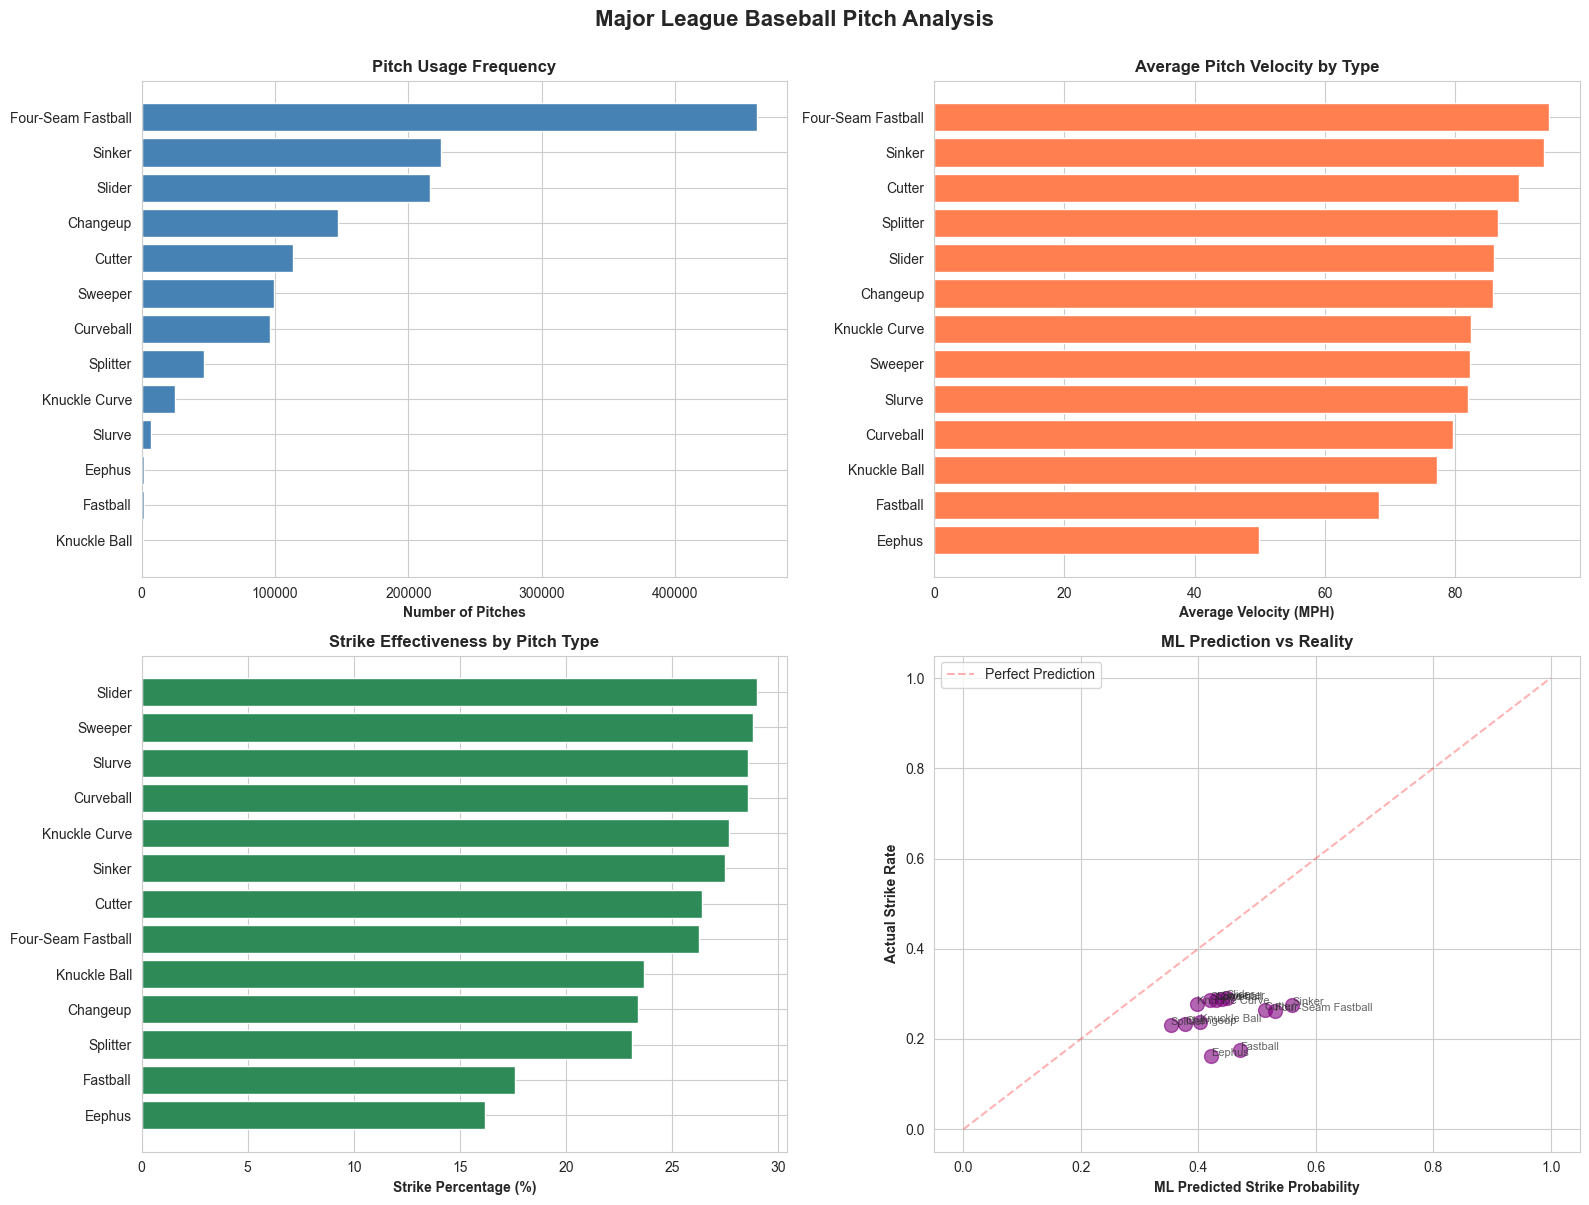


📊 Major League Baseball pitch type analysis complete!


In [9]:
# Create multi-panel visualization for pitch types
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{LEAGUE_LEVEL} Pitch Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Pitch count by type
ax1 = axes[0, 0]
pitch_sorted = pitch_type_df.sort_values('pitch_count', ascending=True)
ax1.barh(pitch_sorted['pitch_type_description'], pitch_sorted['pitch_count'], color='steelblue')
ax1.set_xlabel('Number of Pitches', fontweight='bold')
ax1.set_title('Pitch Usage Frequency', fontsize=12, fontweight='bold')

# 2. Average velocity by pitch type
ax2 = axes[0, 1]
velocity_sorted = pitch_type_df.sort_values('avg_velocity', ascending=True)
ax2.barh(velocity_sorted['pitch_type_description'], velocity_sorted['avg_velocity'], color='coral')
ax2.set_xlabel('Average Velocity (MPH)', fontweight='bold')
ax2.set_title('Average Pitch Velocity by Type', fontsize=12, fontweight='bold')

# 3. Strike percentage by pitch type
ax3 = axes[1, 0]
strike_sorted = pitch_type_df.sort_values('strike_pct', ascending=True)
ax3.barh(strike_sorted['pitch_type_description'], strike_sorted['strike_pct'], color='seagreen')
ax3.set_xlabel('Strike Percentage (%)', fontweight='bold')
ax3.set_title('Strike Effectiveness by Pitch Type', fontsize=12, fontweight='bold')

# 4. ML predicted strike probability vs actual strike rate
ax4 = axes[1, 1]
ax4.scatter(pitch_type_df['avg_strike_prob'], pitch_type_df['strike_pct']/100, s=100, alpha=0.6, color='purple')
for idx, row in pitch_type_df.iterrows():
    ax4.annotate(row['pitch_type_description'], (row['avg_strike_prob'], row['strike_pct']/100), 
                fontsize=8, alpha=0.7)
ax4.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='Perfect Prediction')
ax4.set_xlabel('ML Predicted Strike Probability', fontweight='bold')
ax4.set_ylabel('Actual Strike Rate', fontweight='bold')
ax4.set_title('ML Prediction vs Reality', fontsize=12, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 {LEAGUE_LEVEL} pitch type analysis complete!")


### 💪 Power Hitting Analysis


In [10]:
# Analyze power hitters
print(f"🏆 Top 20 {LEAGUE_LEVEL} Batters by Barrel Rate (Min 100 PA):")

batter_query = f"""
SELECT 
    batter_full_name,
    batter_side_description,
    COUNT(*) as plate_appearances,
    ROUND(AVG(CASE WHEN hit_launch_speed IS NOT NULL THEN hit_launch_speed END), 1) as avg_exit_velo,
    ROUND(AVG(CASE WHEN hit_launch_angle IS NOT NULL THEN hit_launch_angle END), 1) as avg_launch_angle,
    SUM(CASE WHEN hit_trajectory = 'fly_ball' AND hit_total_distance > 400 THEN 1 ELSE 0 END) as long_balls,
    SUM(CASE WHEN hit_launch_speed > 95 AND hit_launch_angle BETWEEN 20 AND 35 THEN 1 ELSE 0 END) as barrels
FROM {full_table_name}
WHERE level = '{LEAGUE_LEVEL}'
GROUP BY batter_full_name, batter_side_description
HAVING COUNT(*) >= 100
ORDER BY barrels DESC
LIMIT 20
"""

batter_df = spark.sql(batter_query).toPandas()
print(batter_df.to_string(index=False))


🏆 Top 20 Major League Baseball Batters by Barrel Rate (Min 100 PA):


     batter_full_name batter_side_description  plate_appearances  avg_exit_velo  avg_launch_angle  long_balls  barrels
        Shohei Ohtani                    Left               6311           95.3              15.8          77      167
          Aaron Judge                   Right               5894           95.8              19.0          72      150
            Juan Soto                    Left               6197           93.6              10.6          55      139
          Pete Alonso                   Right               5837           91.8              15.0          50      137
       Kyle Schwarber                    Left               6066           93.9              17.7          61      133
        Marcell Ozuna                   Right               5539           91.1              14.3          47      130
         Brent Rooker                   Right               4953           91.2              17.4          47      129
          Taylor Ward                   Right   

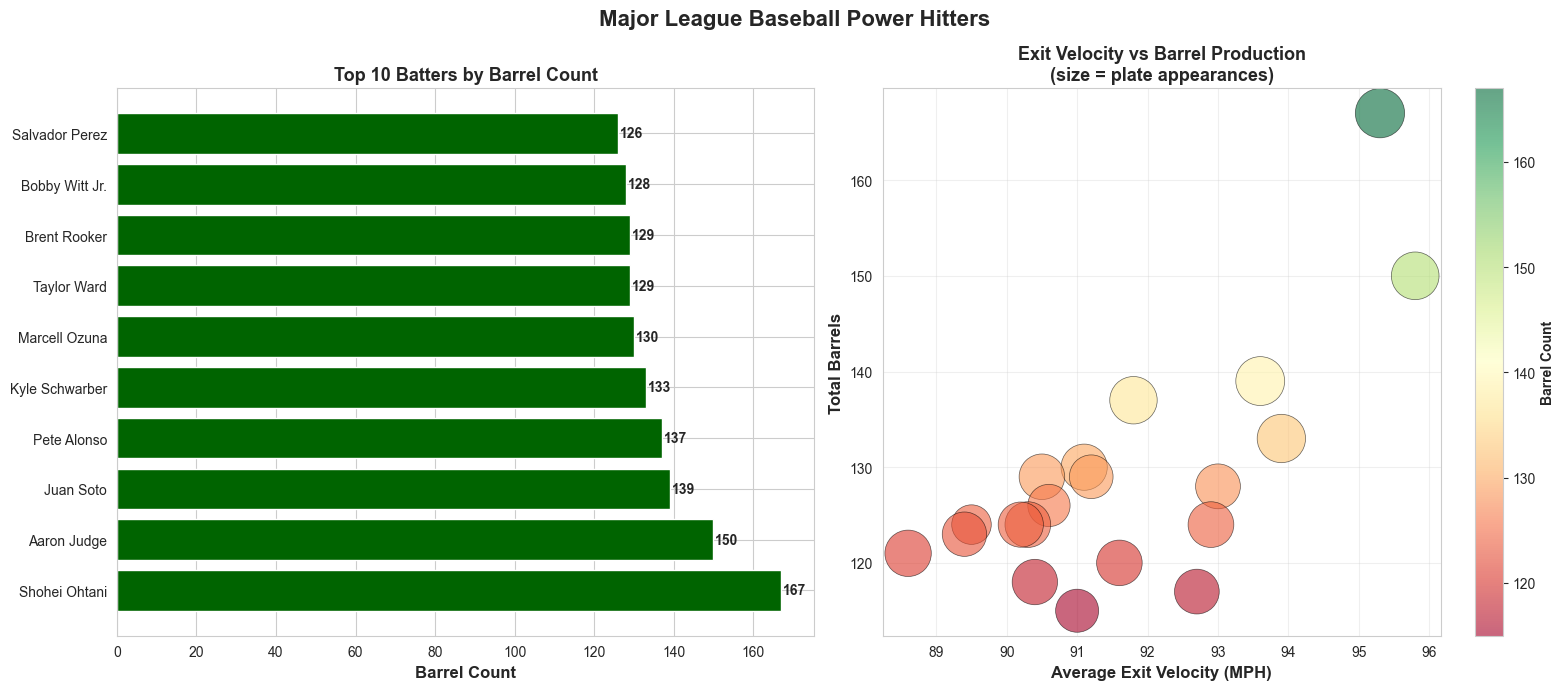


🎯 In Major League Baseball, higher exit velocity generally correlates with more barrels!


In [11]:
# Visualize top power hitters
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'{LEAGUE_LEVEL} Power Hitters', fontsize=16, fontweight='bold')

# Top 10 by barrels
ax1 = axes[0]
top_10_barrels = batter_df.head(10).sort_values('barrels')
bars1 = ax1.barh(top_10_barrels['batter_full_name'], top_10_barrels['barrels'], color='darkgreen')
ax1.set_xlabel('Barrel Count', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Batters by Barrel Count', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Add values on bars
for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            va='center', fontsize=10, fontweight='bold')

# Exit velocity vs barrels scatter
ax2 = axes[1]
scatter = ax2.scatter(batter_df['avg_exit_velo'], batter_df['barrels'], 
                     s=batter_df['plate_appearances']/5, alpha=0.6, c=batter_df['barrels'], 
                     cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Average Exit Velocity (MPH)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Barrels', fontsize=12, fontweight='bold')
ax2.set_title('Exit Velocity vs Barrel Production\n(size = plate appearances)', 
             fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Barrel Count', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🎯 In {LEAGUE_LEVEL}, higher exit velocity generally correlates with more barrels!")


### 📈 Time Series Analysis


In [12]:
# Analyze trends over time
print(f"📈 {LEAGUE_LEVEL} Trends by Season:")

trend_query = f"""
SELECT 
    season,
    ROUND(AVG(pitch_start_speed), 1) as avg_velocity,
    ROUND(AVG(pitch_spin_rate), 0) as avg_spin_rate,
    ROUND(AVG(CASE WHEN hit_launch_speed IS NOT NULL THEN hit_launch_speed END), 1) as avg_exit_velo,
    ROUND(AVG(called_strike_probability), 3) as avg_strike_prob
FROM {full_table_name}
WHERE level = '{LEAGUE_LEVEL}'
GROUP BY season
ORDER BY season
"""

trend_df = spark.sql(trend_query).toPandas()
print(trend_df.to_string(index=False))


📈 Major League Baseball Trends by Season:


 season  avg_velocity  avg_spin_rate  avg_exit_velo  avg_strike_prob
   2024          89.2         2257.0           88.3            0.480
   2025          89.4         2277.0           88.8            0.488


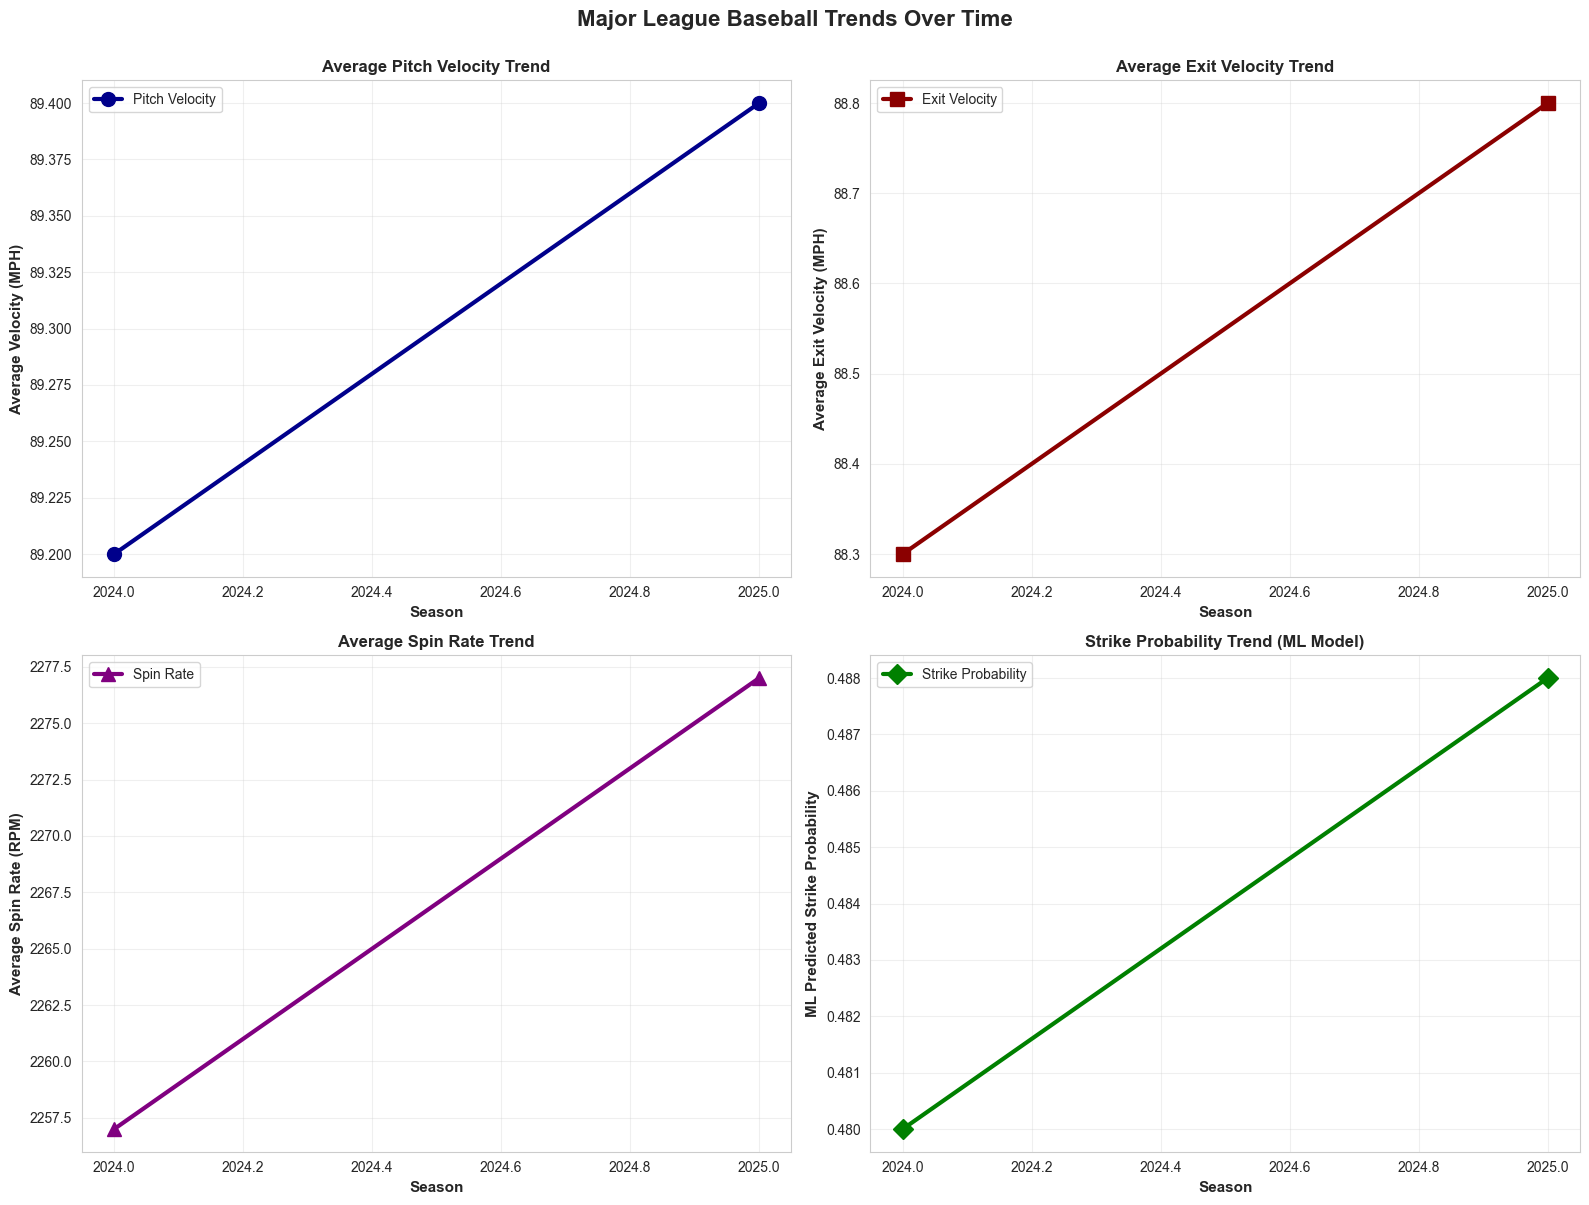


📊 Time series analysis reveals evolving Major League Baseball game dynamics across seasons!


In [13]:
# Visualize trends over time
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{LEAGUE_LEVEL} Trends Over Time', fontsize=16, fontweight='bold', y=1.00)

# 1. Pitch velocity trends
ax1 = axes[0, 0]
ax1.plot(trend_df['season'], trend_df['avg_velocity'], marker='o', linewidth=3, 
         markersize=10, color='darkblue', label='Pitch Velocity')
ax1.set_xlabel('Season', fontweight='bold', fontsize=11)
ax1.set_ylabel('Average Velocity (MPH)', fontweight='bold', fontsize=11)
ax1.set_title('Average Pitch Velocity Trend', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Exit velocity trends
ax2 = axes[0, 1]
ax2.plot(trend_df['season'], trend_df['avg_exit_velo'], marker='s', linewidth=3, 
         markersize=10, color='darkred', label='Exit Velocity')
ax2.set_xlabel('Season', fontweight='bold', fontsize=11)
ax2.set_ylabel('Average Exit Velocity (MPH)', fontweight='bold', fontsize=11)
ax2.set_title('Average Exit Velocity Trend', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Spin rate trends
ax3 = axes[1, 0]
ax3.plot(trend_df['season'], trend_df['avg_spin_rate'], marker='^', linewidth=3, 
         markersize=10, color='purple', label='Spin Rate')
ax3.set_xlabel('Season', fontweight='bold', fontsize=11)
ax3.set_ylabel('Average Spin Rate (RPM)', fontweight='bold', fontsize=11)
ax3.set_title('Average Spin Rate Trend', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Strike probability trends
ax4 = axes[1, 1]
ax4.plot(trend_df['season'], trend_df['avg_strike_prob'], marker='D', linewidth=3, 
         markersize=10, color='green', label='Strike Probability')
ax4.set_xlabel('Season', fontweight='bold', fontsize=11)
ax4.set_ylabel('ML Predicted Strike Probability', fontweight='bold', fontsize=11)
ax4.set_title('Strike Probability Trend (ML Model)', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Time series analysis reveals evolving {LEAGUE_LEVEL} game dynamics across seasons!")


## 3. What's Needed for External Access (Admin Configuration)

For this to work in production, a Databricks admin needs to configure:


### Storage Credential
```sql
CREATE STORAGE CREDENTIAL mlb_s3_credential
WITH (AWS_IAM_ROLE = 'arn:aws:iam::ACCOUNT:role/unity-catalog-role');
```

### External Location
```sql
CREATE EXTERNAL LOCATION mlb_external_loc
URL 's3://your-bucket/mlb-data/'
WITH (STORAGE CREDENTIAL mlb_s3_credential);
```

### Permissions
```sql
GRANT READ FILES ON EXTERNAL LOCATION mlb_external_loc TO `user@company.com`;
GRANT SELECT ON TABLE tech_summit.mlb_gumbo_gold.game_report_iceberg TO `user@company.com`;
```

### Verification
```sql
DESCRIBE EXTENDED tech_summit.mlb_gumbo_gold.game_report_iceberg;
-- Check: Provider=iceberg, Location=s3://...
```


## 4. Cleanup


In [14]:
# Stop Spark session
spark.stop()
print("✅ Spark session stopped")


✅ Spark session stopped


## 5. Summary: OSS Spark vs PyIceberg

This notebook demonstrates **external OSS Spark access** to Unity Catalog managed Iceberg tables with comprehensive analytics and beautiful visualizations.

### 🔄 OSS Spark vs PyIceberg Comparison

| Feature | OSS Spark (This Notebook) | PyIceberg (Notebook 08) |
|---------|---------------------------|-------------------------|
| **Query Language** | SQL + DataFrame API | Python API |
| **Performance** | Distributed (cluster) | Single-node |
| **Best For** | Large-scale analytics | Local exploration |
| **Dependencies** | JVM + Spark | Lightweight Python |
| **Learning Curve** | Moderate | Easy |
| **Credential Vending** | Full support | Limited for managed tables |
| **Zero-Copy to Pandas** | `.toPandas()` | Native `.to_pandas()` |

### 🎯 Key Concepts

1. **REST Catalog Protocol**: Unity Catalog implements Iceberg REST specification
2. **Credential Vending**: Temporary S3 credentials for secure data access
3. **Open Standards**: Apache Iceberg for vendor-neutral table format
4. **Centralized Governance**: Unity Catalog maintains all metadata

### 🏗️ Benefits

- **🔓 No Vendor Lock-in**: Use any Spark platform (EMR, Dataproc, on-prem)
- **💰 Cost Optimization**: Run analytics on your own compute
- **🔐 Security**: Token auth + temporary credentials
- **📊 Governance**: Centralized access control and audit

### 🚀 Use Cases

- Partner data sharing with external organizations
- Multi-cloud analytics workloads
- Cost-effective batch processing
- Legacy system integration
- Development and testing environments

### 📋 When to Use Each Approach

**Use OSS Spark when:**
- Processing large datasets (100GB+)
- Need distributed computation across clusters
- Running on existing Spark infrastructure (EMR, Dataproc, etc.)
- Require complex SQL transformations and joins
- Need enterprise-grade scalability

**Use PyIceberg when:**
- Quick local exploration (<10GB)
- Python-native workflows without JVM overhead
- Jupyter notebook analysis and prototyping
- Simple queries and visualizations
- Minimal dependency requirements

### 🎓 What We Demonstrated

In this notebook, we showed:
- ✅ Spark session configuration with Unity Catalog REST API
- ✅ Credential vending for secure S3 access
- ✅ Comprehensive MLB data analysis with `LEAGUE_LEVEL` filtering
- ✅ Pitcher performance metrics and visualizations
- ✅ Pitch type effectiveness analysis
- ✅ Power hitting (barrel) analysis
- ✅ Time series trends across seasons
- ✅ Beautiful Matplotlib/Seaborn visualizations

---

**This architecture enables vendor-neutral data access with enterprise governance!** ⚾🎉
